# **Evaluación 1 - Machine Learning**


## **Sección 1**

Genere las siguientes imágenes de manera sintética. \\

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

In [1]:
# Import some libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from google.colab.patches import cv2_imshow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Ejercicio 1 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1Z3yNgkQVFJyaCRyTzkjFhIB_3kxqs61q/view?usp=drive_link). \\
**NOTA:** En la salida de la celda puede encontrar el tamaño de la imagen final.

True

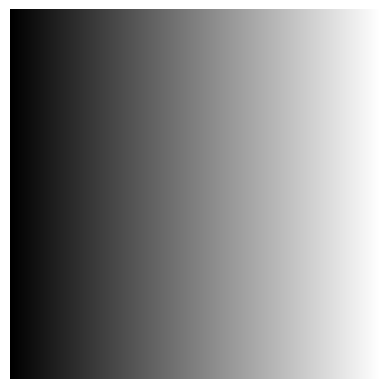

In [3]:
# Tamaño de la imagen
alto = 256
ancho = 256

# Crear una fila con valores de 0 a 255
fila = np.linspace(0, 255, ancho)

# Repetir la fila para crear la imagen completa
imagen = np.tile(fila, (alto,1))

# Convertir a formato de imagen
imagen = imagen.astype(np.uint8)

# Mostrar imagen
plt.imshow(imagen, cmap='gray')
plt.axis('off')

# Guardar imagen
cv2.imwrite('/content/imagen1.png', imagen)

### **Ejercicio 2 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/13z0tvGYD-37_PuHOqoRWHGGmGq7xxvU7/view?usp=drive_link).

True

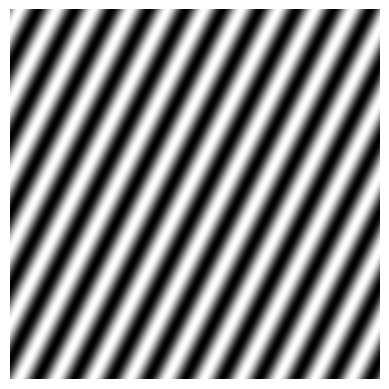

In [10]:
# Resolución
N = 512

# Coordenadas
x = np.linspace(0,1,N)
y = np.linspace(0,1,N)

X, Y = np.meshgrid(x,y)

# Frecuencia
frecuencia = 10

# Control de inclinación
a = 1
b = 0.5

# Patrón sinusoidal
Z = np.sin(2*np.pi*frecuencia*(a*X + b*Y))

# Escala de grises
imagen = 127.5*(1 + Z)
imagen = imagen.astype(np.uint8)

# Mostrar
plt.imshow(imagen, cmap='gray')
plt.axis('off')

# Guardar
cv2.imwrite('/content/imagen2.png', imagen)

## **Sección 2**

Genere las siguientes imágenes usando recorridos por píxeles a partir de [lena.jpg](https://drive.google.com/file/d/1gH5sJN__2g7f9ndLhLvTECdOBJIGUbg_/view?usp=sharing)  y [bengal_tiger.jpg](https://drive.google.com/file/d/1oz8CWUjN7UBNJNq1XOxqzwmYcJRTRmxr/view?usp=sharing)

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

### **Ejercicio 3 (C = 1.6)**

Genere la siguiente animación [resultado](https://drive.google.com/file/d/1jSNhV2CYdm6-E5wuo7o5wE-b2J-_mEil/view?usp=drive_link).

Tamaño de Lena: (220, 220, 3)
Tamaño del Tiger: (220, 221, 3)
Nuevo tamaño Tiger: (220, 220, 3)


(np.float64(-0.5), np.float64(219.5), np.float64(219.5), np.float64(-0.5))

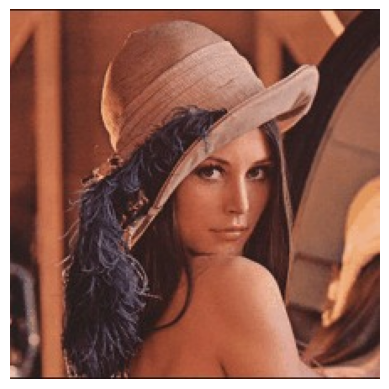

In [20]:
import cv2

lena = cv2.imread('/content/lena.jpg')
tiger = cv2.imread('/content/bengal_tiger.jpg')

print("Tamaño de Lena:", lena.shape)
print("Tamaño del Tiger:", tiger.shape)

# Ajustamos el tamaño de la imagen del tigre para el correcto funcionamiento del ejercicio
tiger = tiger[:, :220, :]

print("Nuevo tamaño Tiger:", tiger.shape)

# Dimensiones
alto, ancho, canales = lena.shape

# Número de frames por transición
num_frames = 40

frames = []

# -----------------------
# Lena -> Tiger
# -----------------------
for k in range(num_frames):

    alpha = k/(num_frames-1)

    frame = np.zeros_like(lena)

    for i in range(alto):
        for j in range(ancho):
            for c in range(canales):

                frame[i,j,c] = int(
                    (1-alpha)*lena[i,j,c] +
                    alpha*tiger[i,j,c]
                )

    frames.append(frame[:,:,::-1])  # BGR → RGB


# -----------------------
# Tiger -> Lena
# -----------------------
for k in range(1, num_frames-1):  # evitamos duplicar extremos

    alpha = k/(num_frames-1)

    frame = np.zeros_like(lena)

    for i in range(alto):
        for j in range(ancho):
            for c in range(canales):

                frame[i,j,c] = int(
                    (1-alpha)*tiger[i,j,c] +
                    alpha*lena[i,j,c]
                )

    frames.append(frame[:,:,::-1])


# Guardar GIF con loop infinito
imageio.mimsave(
    '/content/lena_tiger_infinite.gif',
    frames,
    duration=0.06,
    loop=0   # infinito
)

# Mostrar primer frame
plt.imshow(frames[0])
plt.axis('off')

### **Ejercicio 4 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1UX2Y8Q2xWy5ej0hl_r1B-fKAQ8SX5DI1/view?usp=drive_link).

True

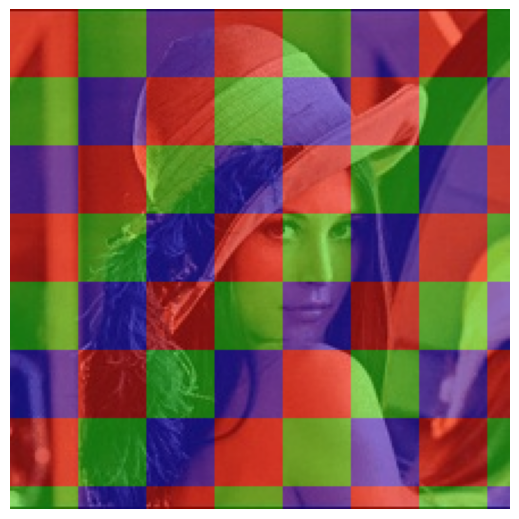

In [58]:
# Cargar imagen
lena = cv2.imread('/content/lena.jpg')

# Dimensiones
alto, ancho, canales = lena.shape

# Parámetros
bloque = 30
alpha = 0.4

# Imagen resultado
resultado = np.zeros_like(lena)

# Recorrido por píxeles
for i in range(alto):
    for j in range(ancho):

        bloque_i = i // bloque
        bloque_j = j // bloque

        patron = (bloque_i + bloque_j) % 3

        B, G, R = lena[i,j]

        # Definir color del bloque
        if patron == 0:
            color = [0,0,255]   # rojo

        elif patron == 1:
            color = [0,255,0]   # verde

        else:
            color = [255,0,0]   # azul

        # Mezcla transparente
        for c in range(3):
            resultado[i,j,c] = int((1-alpha)*lena[i,j,c] + alpha*color[c])

# Mostrar imagen
plt.figure(figsize=(8,5))   # imagen más horizontal
plt.imshow(resultado[:,:,::-1])
plt.axis('off')
plt.tight_layout(pad=0)

# Guardar
cv2.imwrite('/content/lena_mosaico_transparente.png', resultado)

### **Ejercicio 5 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/10jxoa_muSn6bxsDBy7Vw88wz1oirMiRH/view?usp=drive_link)

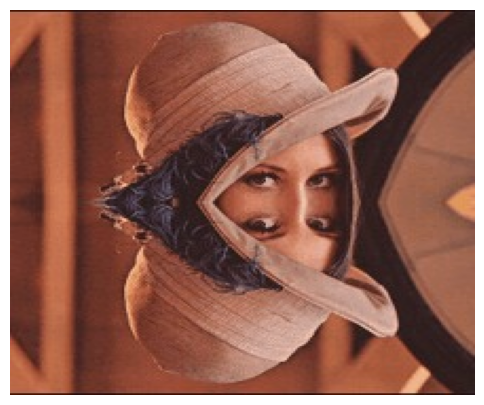

True

In [60]:
# Cargar imagen
lena = cv2.imread('/content/lena.jpg')

# Dimensiones
alto, ancho, canales = lena.shape

# Imagen resultado
resultado = np.zeros_like(lena)

# Recorrer píxeles
for i in range(alto):
    for j in range(ancho):
        for c in range(canales):

            if i < alto // 2:
                # Parte superior igual
                resultado[i,j,c] = lena[i,j,c]
            else:
                # Parte inferior es reflejo de la superior
                fila_reflejo = alto - 1 - i
                resultado[i,j,c] = lena[fila_reflejo,j,c]

# Mostrar imagen
plt.figure(figsize=(6,5))
plt.imshow(resultado[:,:,::-1], aspect='auto')
plt.axis('off')
plt.show()

# Guardar imagen
cv2.imwrite('/content/lena_espejo_final.png', resultado)